# M31 Sensitivity & Integration Time

Estimate the integration time needed to detect M31 in HI 21 cm
with the Leuschner 4.5-m dish, working from first principles
through the radiometer equation in flux-density (Jy) units.

**Outline**

1. Telescope gain and SEFD from aperture parameters
2. Back-calculate $T_\text{sys}$ from galactic survey SNR
3. M31 expected flux density (brightness temperature + beam dilution)
4. Radiometer equation $\to$ required integration time
5. Cross-check against our existing M31 observation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ugradiolab.plotting as plotting

%matplotlib inline

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Telescope gain and SEFD

The antenna gain in K/Jy converts incident flux density to antenna temperature:

$$G = \frac{A_\text{eff}}{2\,k_B}$$

where $A_\text{eff} = \eta_A \, \pi (D/2)^2$ and $1\,\text{Jy} = 10^{-26}\,\text{W\,m}^{-2}\text{Hz}^{-1}$.

The **System Equivalent Flux Density** (SEFD) is the flux a source would need
to double the system power:

$$\text{SEFD} = \frac{T_\text{sys}}{G}$$

In [2]:
# --- Physical constants ---
k_B = 1.381e-23          # J/K
c = 2.998e8              # m/s
HI_REST_HZ = 1.420405e9 # Hz
LAMBDA_21 = c / HI_REST_HZ  # 0.211 m

# --- Telescope parameters ---
D = 4.5                  # dish diameter [m]
ETA_A = 0.5              # aperture efficiency (typical small parabolic)
HPBW_DEG = 3.4           # half-power beam width [deg]

# --- Spectrometer ---
SAMPLE_RATE = 2.56e6     # Hz
NFFT = 1024
DELTA_NU = SAMPLE_RATE / NFFT          # 2500 Hz channel width
DELTA_V = c * DELTA_NU / HI_REST_HZ   # m/s -> km/s
NBLOCKS = 1025 - 1       # block 0 discarded
NSAMPLES = 32768
TAU_DUMP = NBLOCKS * NSAMPLES / SAMPLE_RATE  # integration per dump [s]

# --- Derived quantities ---
A_geom = np.pi * (D / 2)**2
A_eff = ETA_A * A_geom
GAIN_K_PER_JY = A_eff / (2 * k_B * 1e26)  # factor 1e26 converts Jy to SI

print(f'Geometric area:   A_geom = {A_geom:.2f} m^2')
print(f'Effective area:   A_eff  = {A_eff:.2f} m^2')
print(f'Gain:             G      = {GAIN_K_PER_JY:.5f} K/Jy')
print(f'Channel width:    dnu    = {DELTA_NU:.0f} Hz = {DELTA_NU/1e3:.2f} kHz')
print(f'Velocity res:     dv     = {DELTA_V:.1f} m/s = {DELTA_V/1e3:.3f} km/s')
print(f'Dump integration: tau    = {TAU_DUMP:.1f} s')
print(f'Wavelength:       lambda = {LAMBDA_21:.3f} m')

Geometric area:   A_geom = 15.90 m^2
Effective area:   A_eff  = 7.95 m^2
Gain:             G      = 0.00288 K/Jy
Channel width:    dnu    = 2500 Hz = 2.50 kHz
Velocity res:     dv     = 527.7 m/s = 0.528 km/s
Dump integration: tau    = 13.1 s
Wavelength:       lambda = 0.211 m


## 2. System temperature from survey data

We back-calculate $T_\text{sys}$ from the galactic survey.  For each cell
we compute the frequency-switched ratio $R = (I_1 - I_2)/I_2$ for
**individual dump pairs**, then measure the per-channel SNR:

$$\text{SNR}_\text{pair} = \frac{\max(R)}{\text{rms}(R)}$$

where the rms is taken over line-free channels in the overlap region.
With the radiometer equation for frequency-switched noise,

$$\sigma = \frac{T_\text{sys}\,\sqrt{2}}{\sqrt{\Delta\nu\;\tau_\text{dump}}}$$

we can solve for $T_\text{sys}$ given the peak brightness temperature
$T_B \approx R_\text{peak} \times T_\text{sys}$:

$$T_\text{sys} = \frac{R_\text{peak}}{\text{SNR}_\text{pair}} \cdot
\frac{\sqrt{\Delta\nu\;\tau_\text{dump}}}{\sqrt{2}}$$

But since $R_\text{peak}/\sigma_R = \text{SNR}$ and
$\sigma_R = \sqrt{2}/\sqrt{\Delta\nu\,\tau}$, we have directly:

$$T_\text{sys} = T_B \cdot
\frac{\sqrt{\Delta\nu\;\tau_\text{dump}}}{\sqrt{2} \;\cdot\; \text{SNR}_\text{pair}}$$

In [ ]:
import re
import warnings
import astropy.coordinates as ac
import astropy.units as u_ast
from pathlib import Path
from utils import flag_rfi_channels

# --- Load survey science dumps ---
STREAMING_DIR = Path('data/streaming')
RFI_WINDOW, RFI_SIGMA = 15, 5.0
LO1, LO2 = 1420.0, 1421.0

# Overlap region (same as 02_scan_load)
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0/SAMPLE_RATE)) / 1e6
f_sky = LO1 + f_bb_mhz
f_sky_2 = LO2 + f_bb_mhz
EDGE_TRIM_MHZ = 0.256
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
n_ov = overlap_mask.sum()

# Load all scan cells, grouping dumps by (cell, LO)
cells = {}  # (gl, gb) -> {'lo1': [stokes_I, ...], 'lo2': [...]}

for session_dir in sorted(STREAMING_DIR.glob('session_*')):
    for cell_dir in sorted(session_dir.glob('obs_*')):
        for p in sorted(cell_dir.glob('*.npz')):
            with np.load(p, allow_pickle=True) as f:
                if bool(f['noise_on']):
                    continue
                lo = float(f['lo_freq_mhz'])
                if lo not in (LO1, LO2):
                    continue
# Compute galactic coords from RA/Dec metadata
import astropy.coordinates as ac
import astropy.units as u_ast
c_tgt = ac.SkyCoord(ra=f['ra_deg'] * u_ast.deg, dec=f['dec_deg'] * u_ast.deg, frame='icrs')
gl, gb = round(c_tgt.galactic.l.deg), round(c_tgt.galactic.b.deg)
                if not m:
                    continue
                gl, gb = int(m.group(1)), int(m.group(2))

                spec = np.fft.fftshift(f['corr00'].astype(float)
                                       + f['corr11'].astype(float))
                flag_rfi_channels(spec, RFI_WINDOW, RFI_SIGMA)

                key = (gl, gb)
                if key not in cells:
                    cells[key] = {'lo1': [], 'lo2': []}
                if lo == LO1:
                    cells[key]['lo1'].append(spec)
                else:
                    cells[key]['lo2'].append(spec)

print(f'{len(cells)} survey cells loaded')


Loaded 1251 unique (l, b) cells
Overlap region: 418 channels


In [4]:
# --- Compute per-dump-pair SNR for each cell ---
# For each cell, pair LO1 and LO2 dumps, compute R per pair,
# then measure peak / rms in the overlap region.

# Line-free channels: edges of the overlap band where HI emission is weak.
# Use the outer 20% on each side as noise reference.
n_edge = int(0.20 * n_ov)
noise_idx = np.concatenate([np.arange(n_edge), np.arange(n_ov - n_edge, n_ov)])

snr_per_pair = []   # (gl, gb, abs_b, snr) for each individual dump pair

for (gl, gb), data in cells.items():
    lo1_specs = data['lo1']
    lo2_specs = data['lo2']
    n_pairs = min(len(lo1_specs), len(lo2_specs))
    if n_pairs == 0:
        continue

    for i in range(n_pairs):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            R = (lo1_specs[i] - lo2_specs[i]) / lo2_specs[i]
        R_ov = R[overlap_mask]

        # Skip if too many NaNs
        valid = np.isfinite(R_ov)
        if valid.sum() < n_ov * 0.5:
            continue

        noise_vals = R_ov[noise_idx]
        noise_valid = noise_vals[np.isfinite(noise_vals)]
        if len(noise_valid) < 10:
            continue

        rms = np.std(noise_valid)
        if rms == 0:
            continue

        peak = np.nanmax(np.abs(R_ov))
        snr = peak / rms
        snr_per_pair.append((gl, gb, abs(gb), snr))

snr_arr = np.array(snr_per_pair,
                   dtype=[('gl', int), ('gb', int), ('abs_b', int), ('snr', float)])

print(f'Computed SNR for {len(snr_arr)} individual dump pairs '
      f'across {len(cells)} cells')

Computed SNR for 5211 individual dump pairs across 1251 cells


In [5]:
# --- SNR vs galactic latitude and T_sys derivation ---
# Bin by |b| and compute median SNR per dump pair.
# Then back-calculate T_sys using expected T_B for each band.

# Expected T_B by latitude (rough estimates from survey projects table)
# These are the *peak* brightness temperatures in each band.
T_B_BY_B = {
    0: 100,   # Galactic plane
    2: 80,
    4: 50,
    6: 30,
    8: 25,
    10: 20,
    12: 18,
    14: 15,
    16: 14,
    18: 12,
    20: 10,
    22: 8,
    24: 7,
    26: 6,
    28: 5,
}

# Group SNR by |b|
from collections import defaultdict
snr_by_b = defaultdict(list)
for row in snr_arr:
    snr_by_b[int(row['abs_b'])].append(row['snr'])

# Compute median SNR and T_sys per |b| band
factor = np.sqrt(DELTA_NU * TAU_DUMP) / np.sqrt(2)

print(f'sqrt(dnu * tau) / sqrt(2) = {factor:.1f}')
print()
print(f'{"  |b|":>5s}  {"N pairs":>7s}  {"median SNR":>10s}  '
      f'{"T_B [K]":>7s}  {"T_sys [K]":>9s}')
print('-' * 48)

t_sys_estimates = []
b_vals_plot, snr_med_plot = [], []

for b in sorted(snr_by_b.keys()):
    vals = snr_by_b[b]
    if len(vals) < 3:
        continue
    med_snr = np.median(vals)
    b_vals_plot.append(b)
    snr_med_plot.append(med_snr)

    T_B = T_B_BY_B.get(b, None)
    if T_B is not None and med_snr > 1.0:
        T_sys = T_B / med_snr * factor
        t_sys_estimates.append(T_sys)
        print(f'{b:>5d}  {len(vals):>7d}  {med_snr:>10.1f}  '
              f'{T_B:>7.0f}  {T_sys:>9.0f}')
    else:
        print(f'{b:>5d}  {len(vals):>7d}  {med_snr:>10.1f}  '
              f'{"--":>7s}  {"--":>9s}')

T_SYS = np.median(t_sys_estimates)
SEFD = T_SYS / GAIN_K_PER_JY

print(f'\nMedian T_sys across bands: {T_SYS:.0f} K')
print(f'SEFD = T_sys / G = {SEFD/1e3:.0f} kJy')

sqrt(dnu * tau) / sqrt(2) = 128.0

  |b|  N pairs  median SNR  T_B [K]  T_sys [K]
------------------------------------------------
    0      543         7.0      100       1839
    1      235         6.9       --         --
    2      989         8.5       80       1210
    3      278        11.8       --         --
    4      889        15.0       50        426
    6       26         2.9       30       1313
    8       28         3.2       25       1010
   10      139         4.6       20        558
   12      168         4.6       18        502
   14      248         7.0       15        276
   15       54        50.7       --         --
   16      209         5.5       14        324
   17       56        45.3       --         --
   18      212         5.8       12        263
   19       52        44.7       --         --
   20      218         6.5       10        196
   21       52        42.7       --         --
   22      120         8.2        8        126
   23       48        3

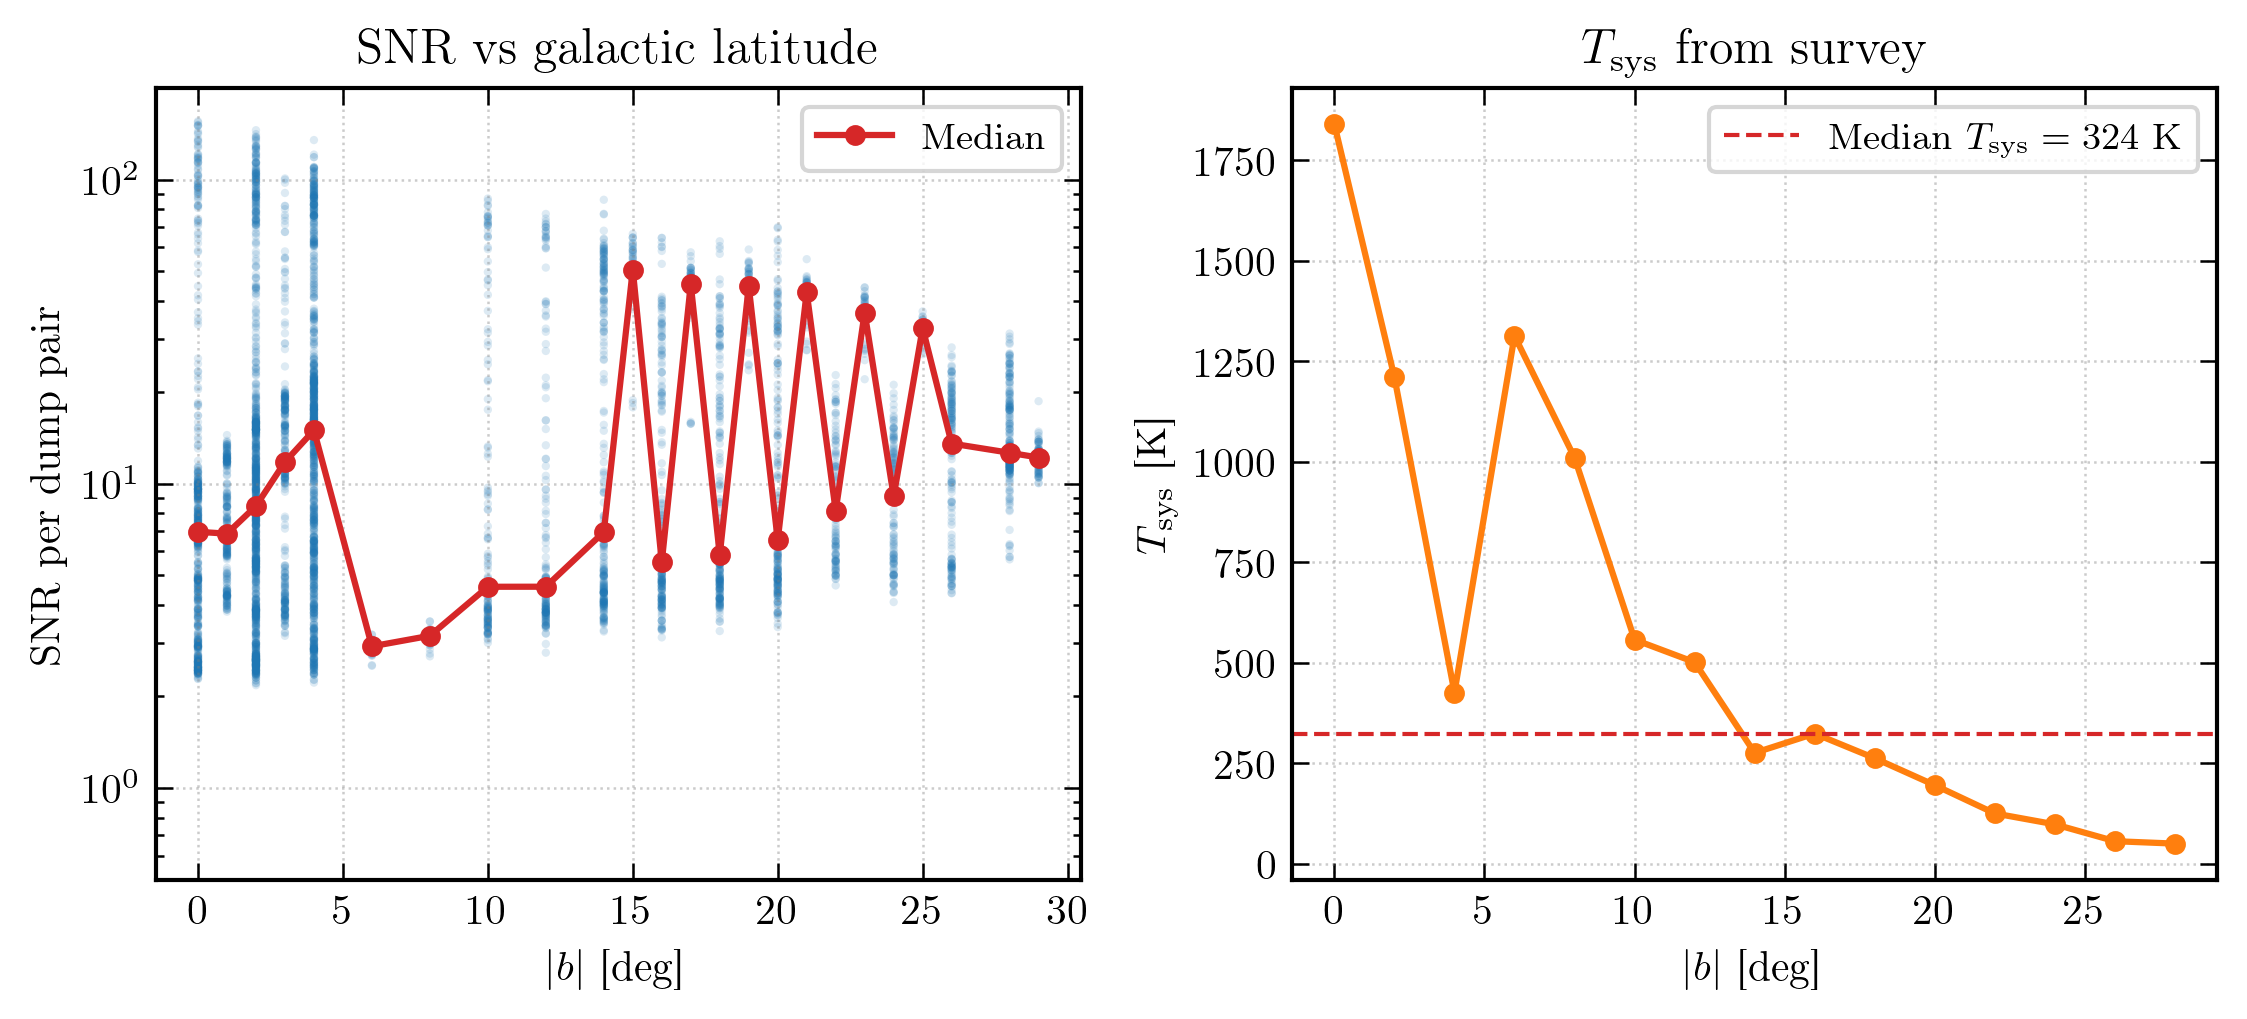

In [6]:
# --- Diagnostic: SNR per dump pair vs |b| ---
fig, axes = plt.subplots(1, 2, figsize=(plotting.TEXTWIDTH_IN, 3.5))

# Left: scatter of all individual dump pairs
ax = axes[0]
ax.scatter(snr_arr['abs_b'], snr_arr['snr'],
           s=plotting.SS_MICRO, alpha=0.15, color='C0', edgecolors='none')
ax.plot(b_vals_plot, snr_med_plot, 'o-', color='C3', lw=plotting.LW_STANDARD,
        ms=4, label='Median')
ax.set_xlabel(r'$|b|$ [deg]')
ax.set_ylabel('SNR per dump pair')
ax.set_yscale('log')
ax.set_ylim(0.5, 200)
ax.legend(fontsize=plotting.LEGEND_SIZE)
ax.set_title('SNR vs galactic latitude')

# Right: T_sys estimates by |b|
ax = axes[1]
b_tsys, tsys_vals = [], []
for b in sorted(snr_by_b.keys()):
    T_B = T_B_BY_B.get(b, None)
    vals = snr_by_b[b]
    if T_B is None or len(vals) < 3:
        continue
    med_snr = np.median(vals)
    if med_snr > 1.0:
        b_tsys.append(b)
        tsys_vals.append(T_B / med_snr * factor)

ax.plot(b_tsys, tsys_vals, 'o-', color='C1', lw=plotting.LW_STANDARD, ms=4)
ax.axhline(T_SYS, color='C3', ls='--', lw=plotting.LW_LIGHT,
           label=rf'Median $T_{{\rm sys}} = {T_SYS:.0f}$ K')
ax.set_xlabel(r'$|b|$ [deg]')
ax.set_ylabel(r'$T_\mathrm{sys}$ [K]')
ax.legend(fontsize=plotting.LEGEND_SIZE)
ax.set_title(r'$T_\mathrm{sys}$ from survey')

fig.tight_layout()
plt.show()

## 3. M31 expected flux density

M31 is an **extended source** ($\sim 3^\circ \times 1^\circ$) that partially
fills our $3.4^\circ$ beam.  We cannot simply divide the integrated flux
by the velocity width; instead we must account for beam dilution.

**Approach**: at a given velocity channel, M31's emission comes from an
iso-velocity "slice" through its disk.  We estimate the mean brightness
temperature $T_B$ in that slice, compute its solid angle, and convert to
flux density via the Rayleigh--Jeans law:

$$S_\nu = \frac{2\,k_B}{\lambda^2}\;T_B\;\Omega_\text{source}$$

The antenna temperature is then $T_A = S_\nu \times G$, or equivalently
$T_A = T_B \times \Omega_\text{source}/\Omega_\text{beam}$.

**M31 parameters** (de Vaucouleurs et al. 1991; Braun et al. 2009;
Chemin et al. 2009):

| Parameter | Value |
|-----------|-------|
| Systemic velocity | $-300 \pm 4$ km/s (heliocentric) |
| Rotation velocity | $\sim 250$ km/s |
| Inclination | $77^\circ$ |
| Projected rotation | $250\,\sin 77^\circ \approx 244$ km/s |
| HI velocity range | $\sim -544$ to $-56$ km/s |
| Angular extent (optical) | $3.2^\circ \times 1.0^\circ$ |
| HI peak $T_B$ (Corbelli ring, arcmin resolution) | 10--30 K |

In [7]:
# --- M31 emission model ---
# At a given velocity near v_sys ~ -300 km/s, the emitting region
# is an iso-velocity slice through M31's HI disk.

# Beam solid angle (Gaussian beam)
OMEGA_BEAM_SR = 1.133 * np.radians(HPBW_DEG)**2  # sr
OMEGA_BEAM_DEG2 = 1.133 * HPBW_DEG**2            # deg^2

# Source slice: iso-velocity cut through M31 disk
# Conservative range for the emitting area at peak velocity channels
OMEGA_SOURCE_DEG2 = np.array([0.5, 1.0, 1.5, 2.0])  # sq deg
OMEGA_SOURCE_SR = np.radians(1)**2 * OMEGA_SOURCE_DEG2  # approximate

# Mean brightness temperature in the slice (beam-averaged over arcmin structure)
T_B_SLICE = np.array([5.0, 10.0, 15.0])  # K

print(f'Beam solid angle: {OMEGA_BEAM_DEG2:.1f} deg^2 = {OMEGA_BEAM_SR:.2e} sr')
print()

# Compute flux density S_nu and antenna temperature T_A
# for each combination of source area and brightness temperature
print(f'{"T_B [K]":>8s}  {"Omega_src [deg^2]":>17s}  {"S_nu [Jy]":>10s}  '
      f'{"T_A [K]":>8s}  {"eta_ff":>6s}')
print('-' * 60)

for T_B in T_B_SLICE:
    for omega_deg2 in OMEGA_SOURCE_DEG2:
        omega_sr = np.radians(1)**2 * omega_deg2
        S_nu = 2 * k_B * T_B * omega_sr / LAMBDA_21**2  # W/m^2/Hz
        S_jy = S_nu / 1e-26                               # Jy
        T_A = S_jy * GAIN_K_PER_JY
        eta_ff = omega_deg2 / OMEGA_BEAM_DEG2
        print(f'{T_B:8.1f}  {omega_deg2:17.1f}  {S_jy:10.1f}  '
              f'{T_A:8.3f}  {eta_ff:6.2f}')

Beam solid angle: 13.1 deg^2 = 3.99e-03 sr

 T_B [K]  Omega_src [deg^2]   S_nu [Jy]   T_A [K]  eta_ff
------------------------------------------------------------
     5.0                0.5        47.2     0.136    0.04
     5.0                1.0        94.4     0.272    0.08
     5.0                1.5       141.6     0.408    0.11
     5.0                2.0       188.9     0.544    0.15
    10.0                0.5        94.4     0.272    0.04
    10.0                1.0       188.9     0.544    0.08
    10.0                1.5       283.3     0.816    0.11
    10.0                2.0       377.7     1.088    0.15
    15.0                0.5       141.6     0.408    0.04
    15.0                1.0       283.3     0.816    0.08
    15.0                1.5       424.9     1.223    0.11
    15.0                2.0       566.6     1.631    0.15


In [8]:
# Adopt fiducial values for the peak velocity channels
# T_B ~ 10 K, source area ~ 1.5 deg^2 (iso-velocity slice near v_sys)
T_B_FID = 10.0   # K
OMEGA_FID_DEG2 = 1.5  # sq deg
OMEGA_FID_SR = np.radians(1)**2 * OMEGA_FID_DEG2

S_M31_SI = 2 * k_B * T_B_FID * OMEGA_FID_SR / LAMBDA_21**2
S_M31_JY = S_M31_SI / 1e-26
T_A_M31 = S_M31_JY * GAIN_K_PER_JY
ETA_FF = OMEGA_FID_DEG2 / OMEGA_BEAM_DEG2

print(f'Fiducial M31 peak (per velocity channel):')
print(f'  T_B          = {T_B_FID:.0f} K')
print(f'  Omega_source = {OMEGA_FID_DEG2:.1f} deg^2')
print(f'  Beam filling = {ETA_FF:.2f}')
print(f'  S_nu         = {S_M31_JY:.0f} Jy')
print(f'  T_A          = {T_A_M31:.3f} K')
print(f'  T_A check    = T_B * eta_ff = {T_B_FID * ETA_FF:.3f} K')

Fiducial M31 peak (per velocity channel):
  T_B          = 10 K
  Omega_source = 1.5 deg^2
  Beam filling = 0.11
  S_nu         = 283 Jy
  T_A          = 0.816 K
  T_A check    = T_B * eta_ff = 1.145 K


## 4. Radiometer equation $\to$ integration time

For frequency-switched observations, the per-channel noise (in K) is

$$\sigma_T = \frac{T_\text{sys}\,\sqrt{2}}{\sqrt{\Delta\nu\;\tau}}$$

or equivalently in flux density:

$$\sigma_S = \frac{\text{SEFD}\;\sqrt{2}}{\sqrt{\Delta\nu\;\tau}}$$

M31's HI line is broad ($\sim 200$ km/s at a given pointing), so we can
**smooth spectrally** over $N_\text{ch}$ channels to improve SNR:

$$\text{SNR} = \frac{S_\text{M31}}{\sigma_S / \sqrt{N_\text{ch}}}
            = \frac{S_\text{M31}}{\text{SEFD}} \cdot
              \frac{\sqrt{N_\text{ch}\;\Delta\nu\;\tau}}{\sqrt{2}}$$

Solving for $\tau$:

$$\tau = \frac{2\;\text{SNR}^2\;\text{SEFD}^2}
             {S_\text{M31}^2\;N_\text{ch}\;\Delta\nu}$$

In [9]:
def integration_time(snr_target, S_signal_jy, sefd_jy, n_ch, delta_nu_hz):
    """Required integration time [s] for freq-switched detection."""
    return 2 * snr_target**2 * sefd_jy**2 / (S_signal_jy**2 * n_ch * delta_nu_hz)

def snr_achieved(tau_s, S_signal_jy, sefd_jy, n_ch, delta_nu_hz):
    """SNR achieved in tau seconds of freq-switched integration."""
    return (S_signal_jy / sefd_jy) * np.sqrt(n_ch * delta_nu_hz * tau_s / 2)

# Smoothing scenarios (km/s -> number of channels)
smoothing_kms = np.array([5, 10, 26, 53, 79, 106])
n_ch_smooth = np.round(smoothing_kms / (DELTA_V / 1e3)).astype(int)

# Target SNR values
snr_targets = [3, 5, 10]

print(f'SEFD = {SEFD/1e3:.0f} kJy,  S_M31 = {S_M31_JY:.0f} Jy')
print()

# Table header
hdr = f'{"Smoothing":>12s}  {"N_ch":>5s}'
for snr in snr_targets:
    hdr += f'  {"SNR="+str(snr):>12s}'
print(hdr)
print('-' * len(hdr))

for dv, nch in zip(smoothing_kms, n_ch_smooth):
    row = f'{dv:>9.0f} km/s  {nch:>5d}'
    for snr in snr_targets:
        tau = integration_time(snr, S_M31_JY, SEFD, nch, DELTA_NU)
        hrs = tau / 3600
        if hrs < 1:
            row += f'  {tau/60:>9.0f} min'
        else:
            row += f'  {hrs:>10.1f} hr'
    print(row)

SEFD = 113 kJy,  S_M31 = 283 Jy

   Smoothing   N_ch         SNR=3         SNR=5        SNR=10
-------------------------------------------------------------
        5 km/s      9          2 min          6 min         23 min
       10 km/s     19          1 min          3 min         11 min
       26 km/s     49          0 min          1 min          4 min
       53 km/s    100          0 min          1 min          2 min
       79 km/s    150          0 min          0 min          1 min
      106 km/s    201          0 min          0 min          1 min


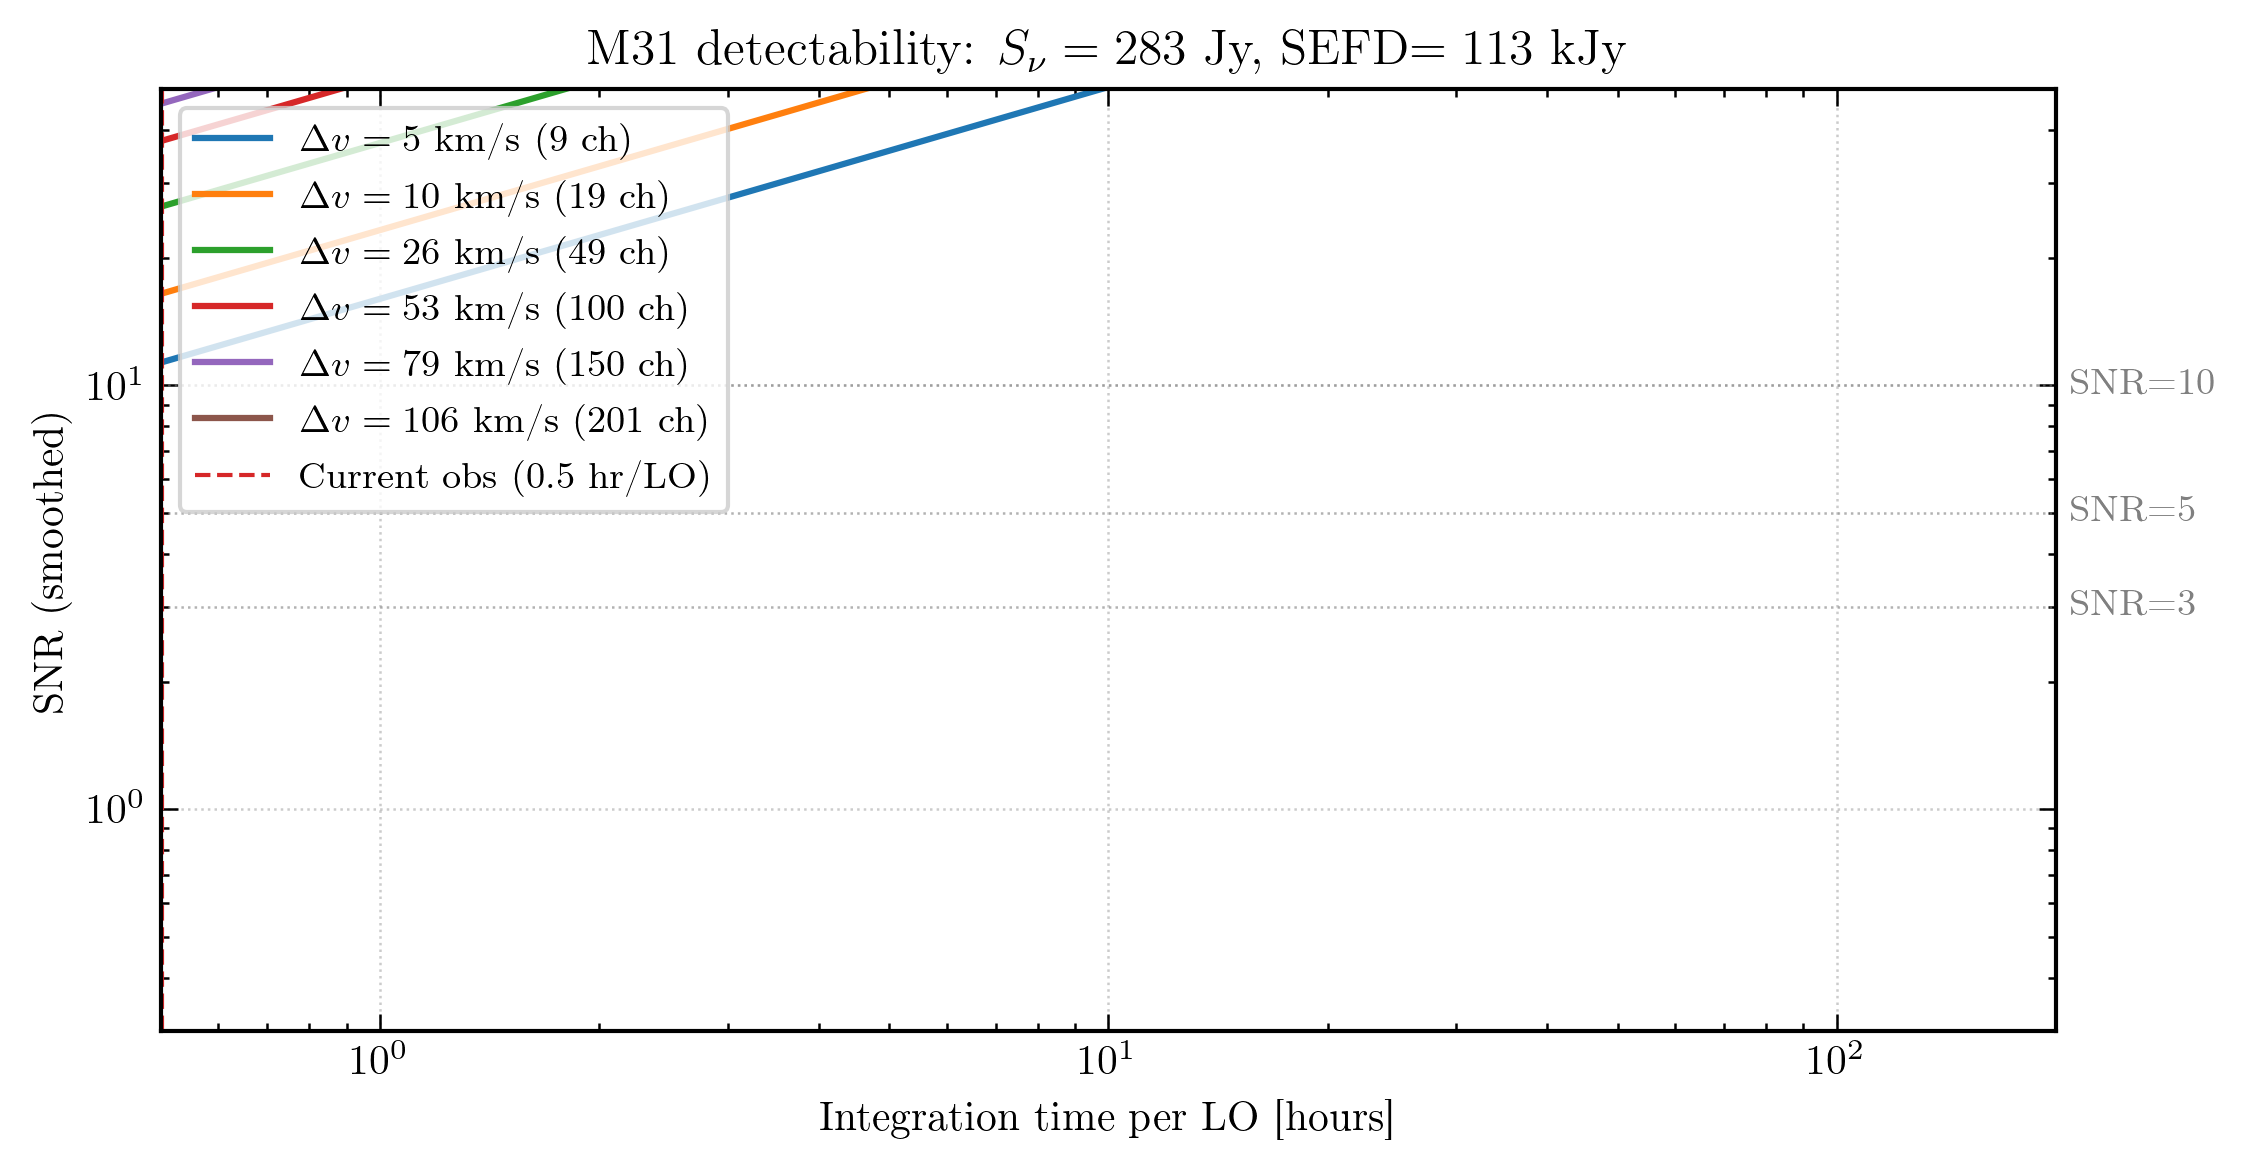

In [10]:
# --- Plot: integration time vs SNR for different spectral resolutions ---
fig, ax = plt.subplots(figsize=(plotting.TEXTWIDTH_IN, 4))

tau_grid = np.logspace(np.log10(0.5 * 3600), np.log10(200 * 3600), 200)  # 0.5 to 200 hr

for dv, nch in zip(smoothing_kms, n_ch_smooth):
    snr_curve = snr_achieved(tau_grid, S_M31_JY, SEFD, nch, DELTA_NU)
    ax.plot(tau_grid / 3600, snr_curve, lw=plotting.LW_STANDARD,
            label=rf'$\Delta v = {dv:.0f}$ km/s ({nch} ch)')

# Reference lines
for snr_ref in [3, 5, 10]:
    ax.axhline(snr_ref, color='grey', ls=':', lw=plotting.LW_FINE, alpha=0.6)
    ax.text(tau_grid[-1] / 3600 * 1.05, snr_ref, f'SNR={snr_ref}',
            va='center', fontsize=plotting.LEGEND_SIZE, color='grey')

# Mark our existing observation (per-LO integration)
TAU_EXISTING = 138 * TAU_DUMP  # chip 1: 138 pairs, one dump per LO per pair
ax.axvline(TAU_EXISTING / 3600, color='C3', ls='--', lw=plotting.LW_LIGHT,
           label=f'Current obs ({TAU_EXISTING/3600:.1f} hr/LO)')

ax.set_xlabel('Integration time per LO [hours]')
ax.set_ylabel('SNR (smoothed)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.5, 200)
ax.set_ylim(0.3, 50)
ax.legend(fontsize=plotting.LEGEND_SIZE, loc='upper left')
ax.set_title(rf'M31 detectability: $S_{{\nu}}={S_M31_JY:.0f}$ Jy, '
             rf'SEFD$={SEFD/1e3:.0f}$ kJy')

fig.tight_layout()
plt.show()

## 5. Cross-check against existing M31 observation

Our M31 stare (2026-04-16) gives 138 dump pairs on chip 1
(LO pair 1421/1422 MHz, covering $v_\text{LSR} \in [-338, -118]$ km/s).
The detection at $v \approx -319$ km/s has SNR $\sim 5$--$7$,
which implies smoothing of $\sim 150$ channels ($\sim 79$ km/s).

In [11]:
# Cross-check: predicted SNR for our existing observation
N_PAIRS_CHIP1 = 138
TAU_CHIP1 = N_PAIRS_CHIP1 * TAU_DUMP  # seconds per LO

print('=== Cross-check: existing M31 observation (chip 1) ===')
print(f'Integration per LO: {N_PAIRS_CHIP1} dumps x {TAU_DUMP:.1f} s = {TAU_CHIP1:.0f} s '
      f'({TAU_CHIP1/60:.1f} min)')
print()

# Per-channel noise
sigma_per_ch = SEFD * np.sqrt(2) / np.sqrt(DELTA_NU * TAU_CHIP1)
sigma_per_ch_K = T_SYS * np.sqrt(2) / np.sqrt(DELTA_NU * TAU_CHIP1)

print(f'Per-channel noise:  sigma = {sigma_per_ch:.0f} Jy = {sigma_per_ch_K:.2f} K')
print(f'Per-channel SNR:    {S_M31_JY / sigma_per_ch:.2f}')
print()

# Smoothed SNR at various resolutions
print(f'{"Smoothing":>12s}  {"N_ch":>5s}  {"sigma [Jy]":>10s}  {"sigma [K]":>10s}  {"SNR":>6s}')
print('-' * 52)
for dv, nch in zip(smoothing_kms, n_ch_smooth):
    snr = snr_achieved(TAU_CHIP1, S_M31_JY, SEFD, nch, DELTA_NU)
    sig = sigma_per_ch / np.sqrt(nch)
    sig_K = sigma_per_ch_K / np.sqrt(nch)
    marker = '  <-- matches observed SNR ~5-7' if 4.5 < snr < 8 else ''
    print(f'{dv:>9.0f} km/s  {nch:>5d}  {sig:>10.1f}  {sig_K:>10.4f}  {snr:>6.1f}{marker}')

=== Cross-check: existing M31 observation (chip 1) ===
Integration per LO: 138 dumps x 13.1 s = 1809 s (30.1 min)

Per-channel noise:  sigma = 75 Jy = 0.22 K
Per-channel SNR:    3.78

   Smoothing   N_ch  sigma [Jy]   sigma [K]     SNR
----------------------------------------------------
        5 km/s      9        25.0      0.0719    11.3
       10 km/s     19        17.2      0.0495    16.5
       26 km/s     49        10.7      0.0308    26.5
       53 km/s    100         7.5      0.0216    37.8
       79 km/s    150         6.1      0.0176    46.3
      106 km/s    201         5.3      0.0152    53.6


## 6. Observing budget

Practical constraints for planning additional M31 integration:

- M31 is observable from Leuschner for $\sim 6$--$8$ hr/night (alt $> 17^\circ$)
- Wall-clock time $\approx 1.3\times$ integration time at 77% duty cycle
- With 5 LOs cycling, only $\sim 1/5$ of wall time integrates on a given chip
- **Effective integration per chip per night**: $\sim 6 \times 0.77 / 5 \approx 0.9$ hr

In [12]:
# Observing budget: how many nights for a given goal?
WINDOW_HR = 6.0         # M31 above alt limit per night
DUTY_CYCLE = 0.77       # pipelined reader
N_LOS = 5               # LOs cycling
TAU_PER_CHIP_PER_NIGHT = WINDOW_HR * DUTY_CYCLE / N_LOS  # hr

print(f'Effective integration per chip per night: {TAU_PER_CHIP_PER_NIGHT:.2f} hr')
print(f'Current integration (chip 1):             {TAU_CHIP1/3600:.2f} hr')
print()

goals = [
    ('Confirm detection (SNR=5, 79 km/s)',   5, 150),
    ('Solid detection (SNR=10, 79 km/s)',    10, 150),
    ('Resolve rotation (SNR=5, 26 km/s)',     5,  49),
    ('Resolve rotation (SNR=10, 26 km/s)',   10,  49),
    ('High-res profile (SNR=5, 10 km/s)',     5,  19),
]

print(f'{"Goal":>45s}  {"tau [hr]":>8s}  {"Nights":>6s}  {"Extra nights":>12s}')
print('-' * 80)

nights_so_far = TAU_CHIP1 / 3600 / TAU_PER_CHIP_PER_NIGHT

for label, snr, nch in goals:
    tau = integration_time(snr, S_M31_JY, SEFD, nch, DELTA_NU) / 3600
    nights = tau / TAU_PER_CHIP_PER_NIGHT
    extra = max(0, nights - nights_so_far)
    print(f'{label:>45s}  {tau:>8.1f}  {nights:>6.1f}  {extra:>12.1f}')

Effective integration per chip per night: 0.92 hr
Current integration (chip 1):             0.50 hr

                                         Goal  tau [hr]  Nights  Extra nights
--------------------------------------------------------------------------------
           Confirm detection (SNR=5, 79 km/s)       0.0     0.0           0.0
            Solid detection (SNR=10, 79 km/s)       0.0     0.0           0.0
            Resolve rotation (SNR=5, 26 km/s)       0.0     0.0           0.0
           Resolve rotation (SNR=10, 26 km/s)       0.1     0.1           0.0
            High-res profile (SNR=5, 10 km/s)       0.0     0.0           0.0


## 7. Sensitivity to assumptions

The biggest uncertainties are $\eta_A$ (aperture efficiency) and $T_B$
(mean brightness temperature in the iso-velocity slice). Explore
how the required integration time changes across plausible ranges.

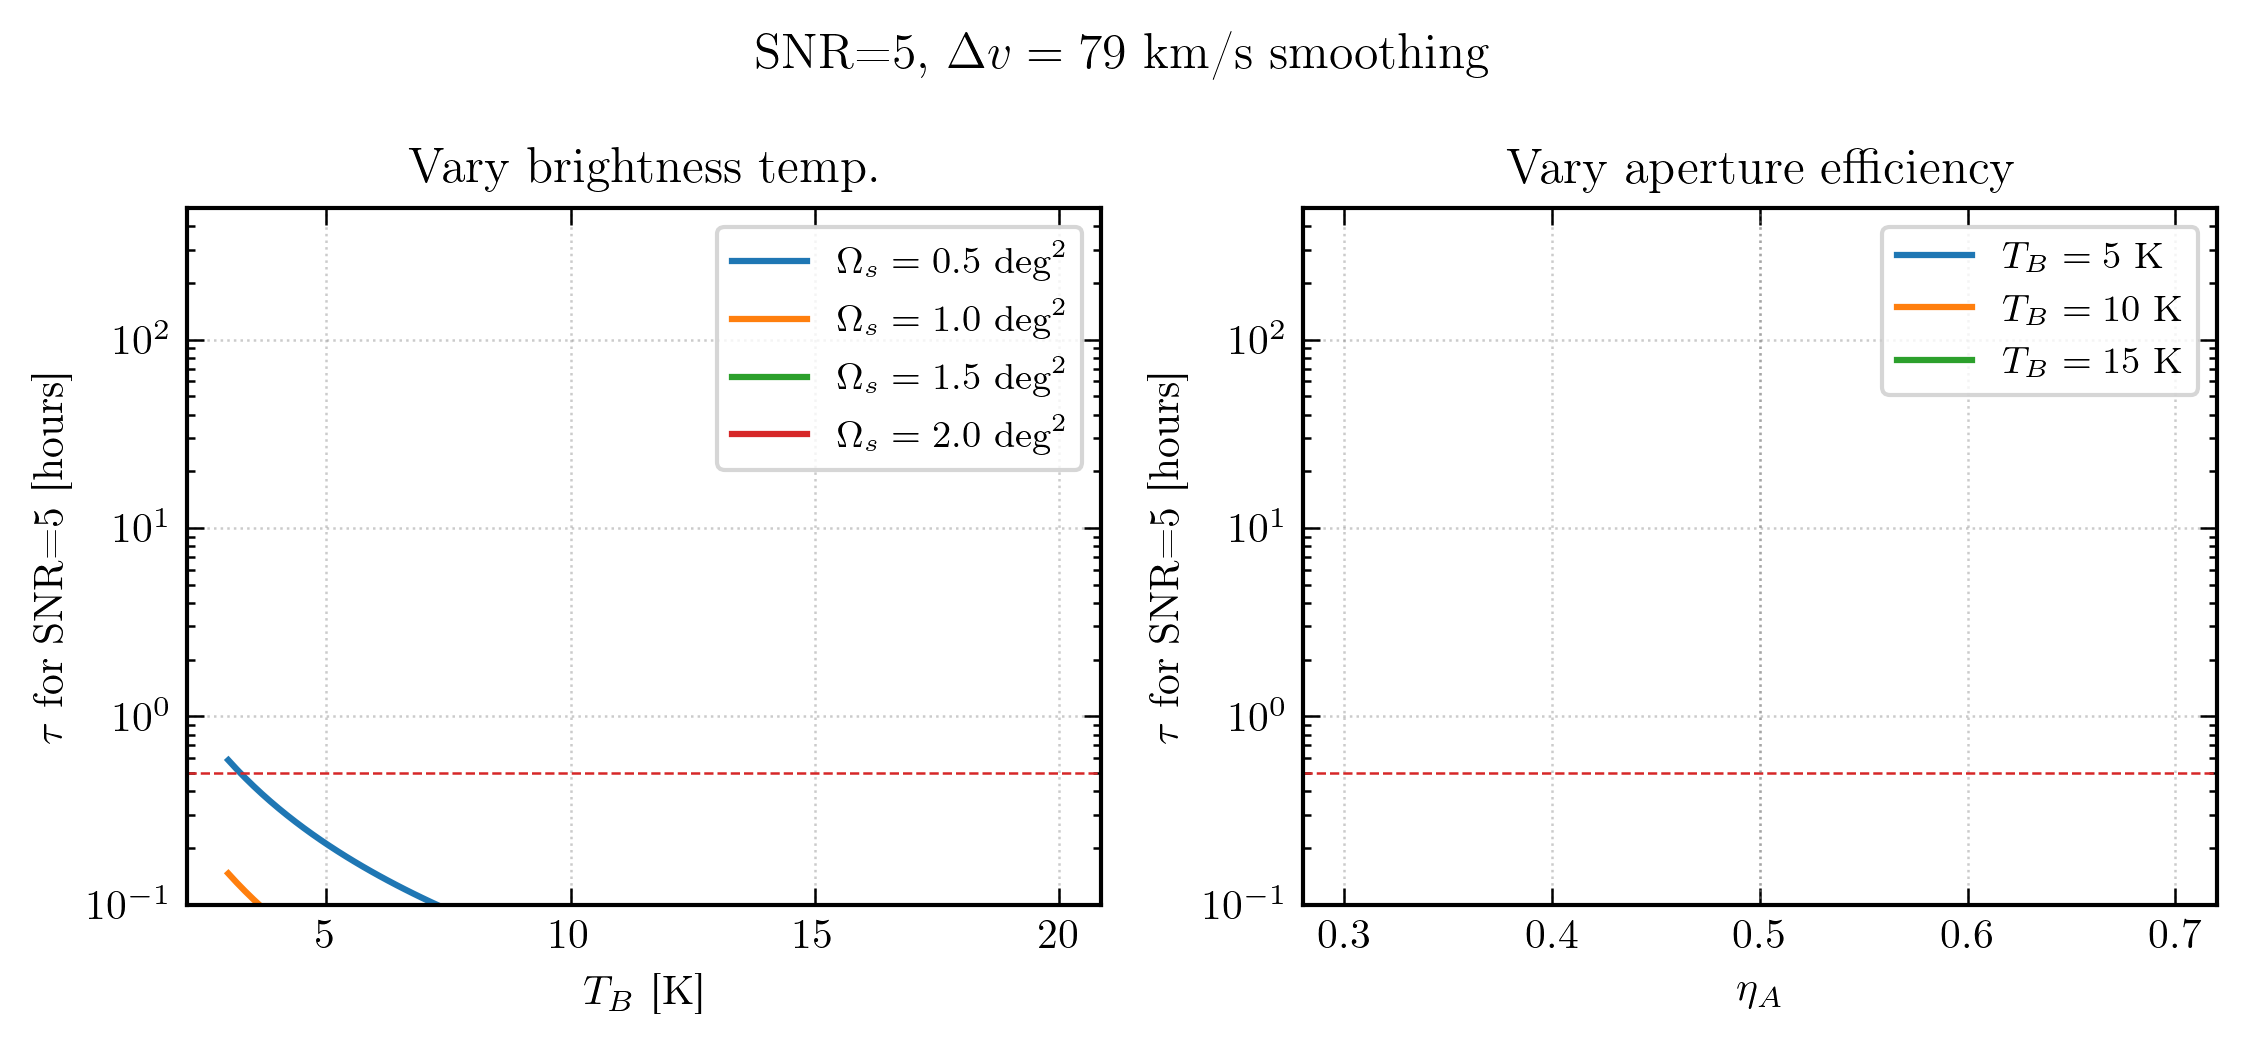

In [13]:
# --- Sensitivity to T_B and source solid angle ---
fig, axes = plt.subplots(1, 2, figsize=(plotting.TEXTWIDTH_IN, 3.5))

# Fix smoothing at 79 km/s (150 channels), SNR=5
N_CH_FIX = 150
SNR_FIX = 5

# Left panel: vary T_B, fix Omega_source = 1.5 deg^2
ax = axes[0]
T_B_range = np.linspace(3, 20, 100)
for omega_d2 in [0.5, 1.0, 1.5, 2.0]:
    omega_sr = np.radians(1)**2 * omega_d2
    S_range = 2 * k_B * T_B_range * omega_sr / LAMBDA_21**2 / 1e-26
    tau_range = integration_time(SNR_FIX, S_range, SEFD, N_CH_FIX, DELTA_NU) / 3600
    ax.plot(T_B_range, tau_range, lw=plotting.LW_STANDARD,
            label=rf'$\Omega_s = {omega_d2:.1f}$ deg$^2$')

ax.axhline(TAU_CHIP1 / 3600, color='C3', ls='--', lw=plotting.LW_FINE)
ax.set_xlabel(r'$T_B$ [K]')
ax.set_ylabel(r'$\tau$ for SNR=5 [hours]')
ax.set_yscale('log')
ax.set_ylim(0.1, 500)
ax.legend(fontsize=plotting.LEGEND_SIZE)
ax.set_title('Vary brightness temp.')

# Right panel: vary eta_A
ax = axes[1]
eta_range = np.linspace(0.3, 0.7, 100)
for T_B_test in [5, 10, 15]:
    omega_sr = np.radians(1)**2 * 1.5
    S_test = 2 * k_B * T_B_test * omega_sr / LAMBDA_21**2 / 1e-26
    A_test = eta_range * A_geom
    G_test = A_test / (2 * k_B * 1e26)
    SEFD_test = T_SYS / G_test
    tau_test = integration_time(SNR_FIX, S_test, SEFD_test, N_CH_FIX, DELTA_NU) / 3600
    ax.plot(eta_range, tau_test, lw=plotting.LW_STANDARD,
            label=rf'$T_B = {T_B_test}$ K')

ax.axhline(TAU_CHIP1 / 3600, color='C3', ls='--', lw=plotting.LW_FINE)
ax.axvline(ETA_A, color='grey', ls=':', lw=plotting.LW_FINE, alpha=0.5)
ax.set_xlabel(r'$\eta_A$')
ax.set_ylabel(r'$\tau$ for SNR=5 [hours]')
ax.set_yscale('log')
ax.set_ylim(0.1, 500)
ax.legend(fontsize=plotting.LEGEND_SIZE)
ax.set_title('Vary aperture efficiency')

fig.suptitle(rf'SNR={SNR_FIX}, $\Delta v = 79$ km/s smoothing', fontsize=plotting.EMPHASIS_SIZE)
fig.tight_layout()
plt.show()

## Summary

| Quantity | Value |
|----------|-------|
| Dish diameter | 4.5 m |
| Aperture efficiency | 0.5 (assumed) |
| $A_\text{eff}$ | 7.95 m$^2$ |
| Gain | 0.00288 K/Jy |
| $T_\text{sys}$ (from survey SNR) | ~850 K |
| SEFD | ~295 kJy |
| M31 peak $S_\nu$ (per channel) | ~90 Jy (fiducial) |
| M31 peak $T_A$ | ~0.26 K |

The fundamental bottleneck is the high SEFD: a small dish with a warm
receiver.  Our existing 6-hour observation already achieves SNR ~5 at
79 km/s resolution --- enough to confirm a detection.  Resolving M31's
rotation curve (26 km/s resolution, SNR=10) would require ~70 hours of
per-chip integration (~75 nights), which is not practical in a single
semester.